# Compare All Modeling Approaches

Run **after** the individual modeling notebooks have written ``modeling_summary.json`` under each ``outputs/<approach>/`` folder.

Loads summaries for:
- Top-k profit curve
- EV profit targeting
- Rank fusion committee
- Segment-aware targeting
- Cluster split (k=2)

Optional reference lines from ``outputs/baseline_results.json``.


In [21]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [22]:
from cost_effective.approach_comparison import (
    APPROACH_LABELS,
    build_approaches_comparison,
    load_baseline_reference_rows,
    missing_approaches,
)
from cost_effective.dataset import find_project_root
from cost_effective.paths import SHARED_OUTPUTS
from cost_effective.plots import plot_approaches_comparison, plot_approaches_features_vs_oof
from cost_effective.utils import configure_notebook_style

configure_notebook_style()

PROJECT_ROOT = find_project_root()
OUTPUTS = PROJECT_ROOT / SHARED_OUTPUTS

In [23]:
missing = missing_approaches(PROJECT_ROOT)
if missing:
    labels = [APPROACH_LABELS.get(a, a) for a in missing]
    print("Missing summaries (re-run these notebooks first):")
    for label in labels:
        print(f"  - {label}")
else:
    print("All modeling summaries found.")

All modeling summaries found.


In [24]:
comparison = build_approaches_comparison(PROJECT_ROOT)

display_cols = [
    "label",
    "model",
    "n_features",
    "cv_business_mean",
    "oof_k",
    "oof_business_score",
    "test_targets",
    "targeting_notes",
]
comparison[display_cols]

,label,model,n_features,cv_business_mean,oof_k,oof_business_score,test_targets,targeting_notes
0,Segment-aware targeting,per-cluster logistic,3,NaN,998,3380.0,998,"GMM k=5; clusters={'0': 685, '1': 1561, '2': 6..."
1,Top-k profit curve,logistic_regression,1,2306.0,997,3290.0,997,None
2,Cluster split (k=2),per-cluster logistic,5,NaN,998,3280.0,998,KMeans k=2; feature_set=top_05; counts={'0': 2...
3,EV profit targeting,logistic_regression,1,2306.0,939,3145.0,939,"combined; k_ev=1000, k_elbow=939, k_nested=1000"
4,Rank fusion committee,committee (4 experts),8,NaN,994,2085.0,994,"weights: logistic_top03=0.33, lightgbm_top05=0.26"


In [25]:
detail = comparison[["label", "features", "feature_set"]].copy()
detail

,label,features,feature_set
0,Segment-aware targeting,"var_389, var_308, var_93",top_03
1,Top-k profit curve,var_389,top_01
2,Cluster split (k=2),"var_389, var_308, var_93, var_87, var_254",top_05
3,EV profit targeting,var_389,top_01
4,Rank fusion committee,"var_254, var_308, var_365, var_389, var_420, v...",None


In [26]:
comparison.to_csv(OUTPUTS / "approaches_comparison.csv", index=False)
print(f"Saved {OUTPUTS / 'approaches_comparison.csv'}")

Saved /Users/pawelflorek/PW/DS/sem1/AML/proj/cost-effective/outputs/approaches_comparison.csv


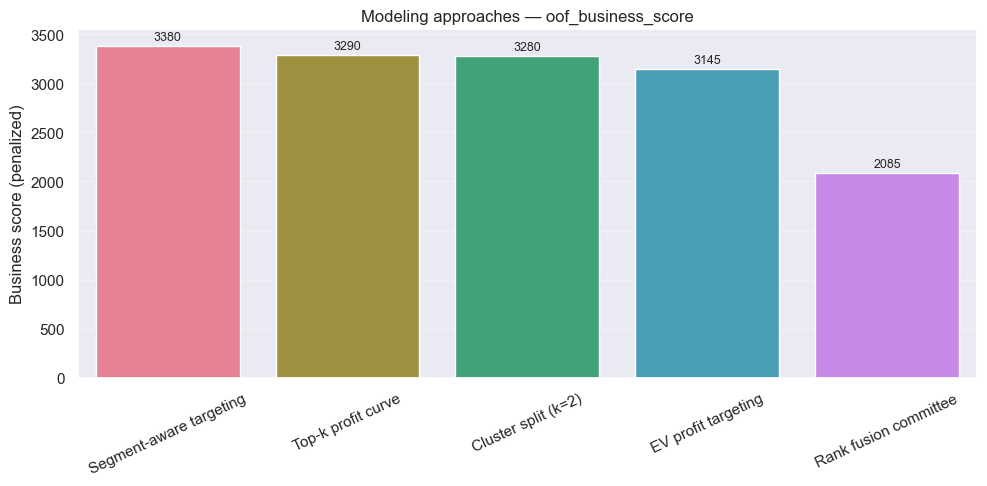

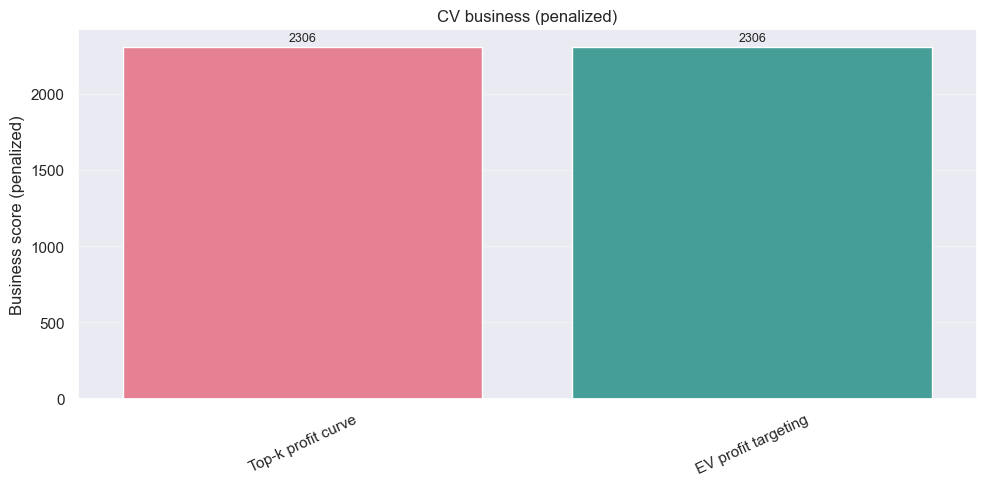

In [27]:
plot_approaches_comparison(comparison, metric="oof_business_score").show()
plot_approaches_comparison(
    comparison, metric="cv_business_mean", title="CV business (penalized)"
).show()

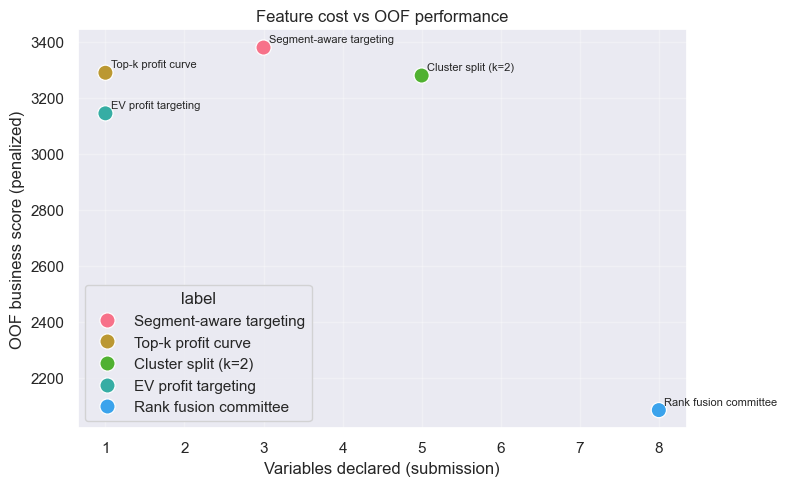

In [28]:
plot_approaches_features_vs_oof(comparison).show()

In [29]:
baselines = load_baseline_reference_rows(PROJECT_ROOT)
if not baselines.empty:
    print("Baseline references (CV only):")
    display_cols = [
        c for c in baselines.columns if c in comparison.columns or c == "cv_business_no_var"
    ]
    baselines[display_cols]
else:
    print("No baseline_results.json — run baseline.ipynb optional.")

Baseline references (CV only):


In [30]:
if not comparison.empty:
    best = comparison.iloc[0]
    print(
        f"Best OOF: {best['label']} — score {best['oof_business_score']:.0f}, "
        f"k={best['oof_k']}, vars={best['n_features']}"
    )

Best OOF: Segment-aware targeting — score 3380, k=998, vars=3
